In [1]:
import matplotlib.pyplot as plt
import torch
from cryosim.plotting_tools import plot3d
from cryosim.imagegenerator import TiltSeriesGenerator
from cryosim.pdbtools import PDB
from cryosim.potential import PotentialBuilder
import numpy as np

%load_ext autoreload
%autoreload 2

In [2]:
# doesn't work.
# L.seed_everything(0)
# torch.use_deterministic_algorithms(True)

In [3]:
# fetch pdb file
pdb_code = "6bdf"
assembly = True  # True: fetches assembly. False: fetches subunit. int: fetches specific assembly #int
pdb = PDB(pdb_code, assembly=True, savefolder="../pdb-data/")

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.


Output()

In [4]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 1  # angstrom, pixel size.
device = "cpu"
pb = PotentialBuilder(n, dx, pdb.atomic_numbers).to(device)

In [5]:
with torch.no_grad():
    V = pb(pdb.coordinates).clone()

Output()

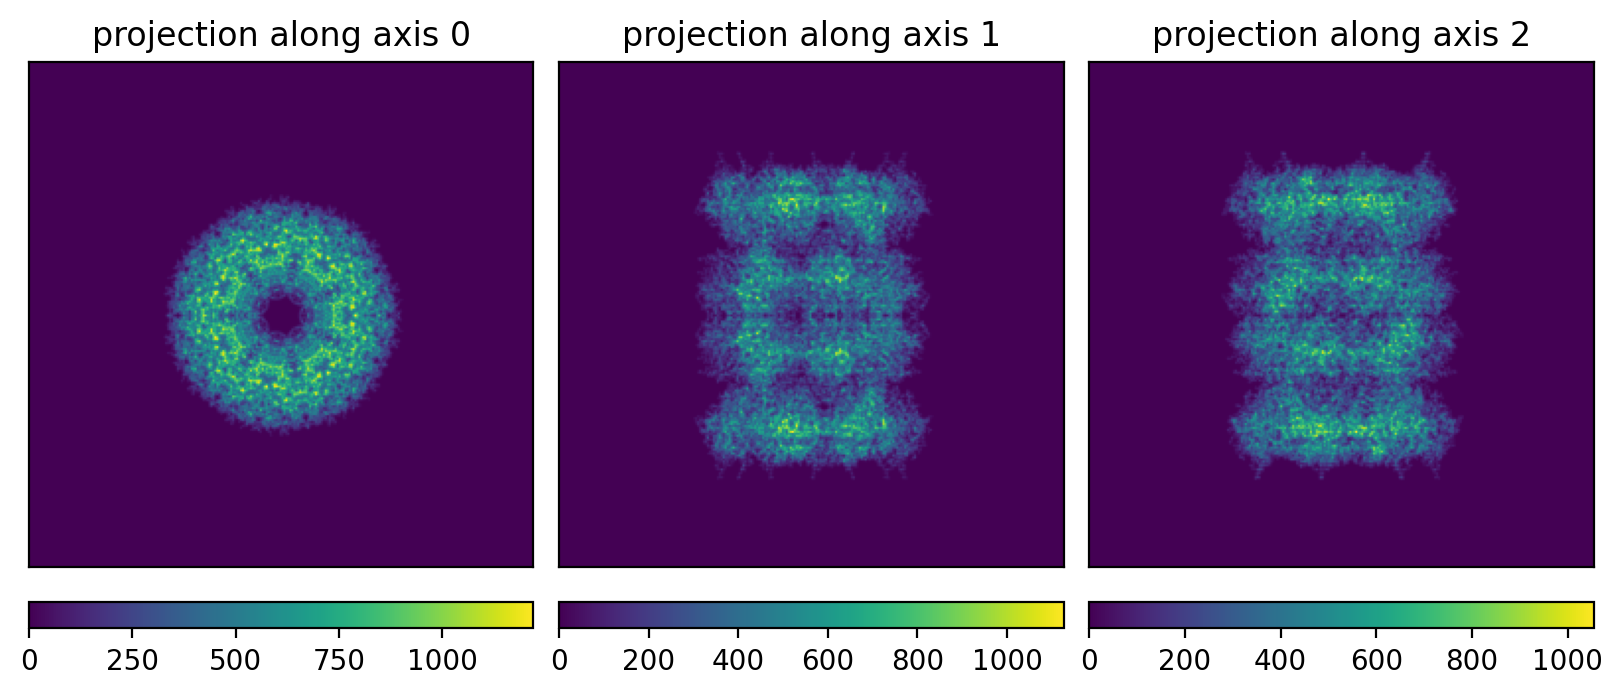

In [6]:
plot3d(V)

## Micrograph class

In [7]:
n_micrographs = 1
energy = 300  # keV
dose_per_angstrom = 20  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1
micrograph_size = 2048

In [8]:
# random defocus
defocus_min = 5000  # angstrom
defocus_max = 15000  # angstrom
defocus_A = torch.rand(n_micrographs) * (defocus_max - defocus_min) + defocus_min


# Can include 'cs', 'dfu', 'dfv', 'dfang', 'tiltx', 'tilty', 'phaseshift', 'trefoil1, 'trefoil2'
ctf_params = {
    "cs": torch.tensor([Cs] * n_micrographs),
    "dfu": defocus_A,
}

In [9]:
device = "cuda:0"  # choose cpu if you run out of cuda memory.

In [ ]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'

noise_model = "poisson"  # 'poisson' or None
# noise_model = None

ice_model = "iterative"  # 'randomchoice' for fast & inaccurate, 'iterative' for slow & accurate, or None
# ice_model = None

ice_thickness = 500  # angstroms, set to 0 for minimum ice thickness = particle box size

crowd_min_distance = pdb.max_diameter  # angstroms, set to None for no crowding
# crowd_min_distance = None

crowd_max_distance_z = (
    ice_thickness - 0.9 * crowd_min_distance
)  # Ensures whole particle is within ice block.

# pad_fft = False  # True to avoid edge artifacts when if crowd_min_distance is not None
pad_fft = False

chunk_size = 8  # set to None for no chunking (cuda memory might exceed)

scaling_factor = 1

angles = torch.linspace(0, 45, 10)

model = TiltSeriesGenerator(
    V * scaling_factor,
    micrograph_size,
    dx,
    ctf_params,
    energy,
    dose_per_angstrom,
    angles,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    alpha=alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=crowd_max_distance_z,
    pad_fft=pad_fft,
    chunk_size=chunk_size,
    move_to_cpu=True,
).to(device)

Auto-calculated sample size: 3398 (Max angle: 45.0 deg)


Output()

Output()

Output()

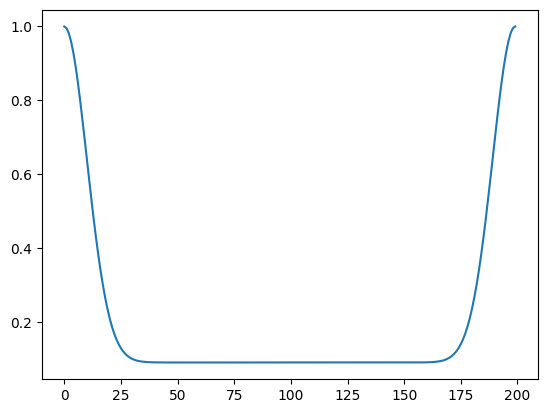

In [20]:
plt.plot(model.crowd.z_distribution)

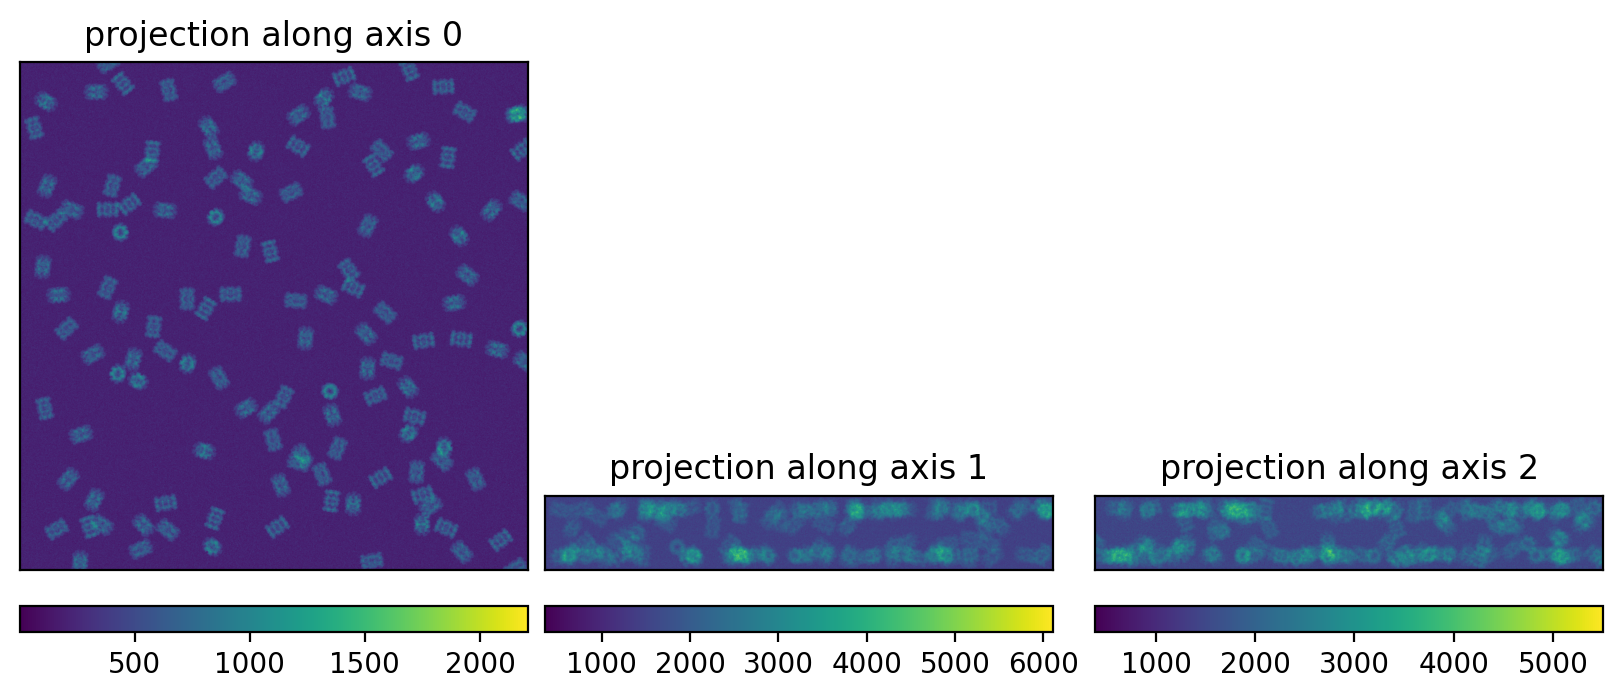

In [21]:
plot3d(model.vol[0])

In [22]:
idx = torch.arange(n_micrographs)

In [37]:
with torch.no_grad():
    tilt_series = model.generate_tilt_series(idx)

Output()

KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 5, dpi=200, constrained_layout=True)
for i, ax in enumerate(axes.ravel()):
    ax.imshow(tilt_series[0, i].detach().cpu(), cmap="grey")
    ax.set(xticks=[], yticks=[])
plt.show()

In [ ]:
import imageio.v2 as imageio

# your tensor: shape (5, 1024, 1024)
imgs = tilt_series[0].cpu().numpy()

frames = []

for i in range(imgs.shape[0]):
    fig, ax = plt.subplots(figsize=(5, 5), dpi=200)
    ax.imshow(imgs[i], cmap="gray", vmax=30, vmin=10)
    ax.axis("off")
    ax.set(title=f"{angles[i]}$^\circ$")

    fig.canvas.draw()

    # Get RGBA buffer → convert to RGB
    buf = np.asarray(fig.canvas.renderer.buffer_rgba())
    frame = buf[:, :, :3]  # drop alpha channel

    frames.append(frame)
    plt.close(fig)

# Save GIF at 2 FPS
imageio.mimsave("output_2048_noisy.gif", frames, fps=2, loop=0)